In [15]:
#pip install yfinance

In [16]:
#pip install mplfinance

In [17]:
import numpy as np
import pandas as pd
import os

import seaborn as sns
import matplotlib.pyplot as plt

import yfinance as yf
import mplfinance as mpf

### 📌 List of 20 Large Technology Companies Listed on the **Stock Exchange of Thailand (SET)**

This list includes major technology companies in Thailand based on **market capitalization** and **sector classification** as of **January 1, 2025**.

| **Company Name** | **Symbol** | **Sector** |
|-----------------|-----------|-------------------------------|
| Delta Electronics (Thailand) | DELTA | Electronic Components |
| Advanced Info Service | ADVANC | Information & Communication Technology |
| Intouch Holdings | INTUCH | Information & Communication Technology |
| KCE Electronics | KCE | Electronic Components |
| Hana Microelectronics | HANA | Electronic Components |
| COM7 Public Company Limited | COM7 | Commerce |
| Synnex (Thailand) | SYNEX | Electronics & Computer Distribution |
| SiS Distribution (Thailand) | SIS | Electronics & Computer Distribution |
| Forth Corporation | FORTH | Electronic Components |
| SVI Public Company Limited | SVI | Electronic Components |
| Sky ICT Public Company Limited | SKY | Information Technology Services |
| Thaicom Public Company Limited | THCOM | Communication Equipment |
| Internet Thailand Public Company Limited | INET | Information Technology Services |
| Humanica Public Company Limited | HUMAN | Software—Application |
| Netbay Public Company Limited | NETBAY | Software—Application |
| Interlink Communication Public Company Ltd | ILINK | Communication Equipment |
| Metro Systems Corporation Public Co. Ltd | MSC | Electronics & Computer Distribution |
| Premier Technology Public Company Limited | PT | Information Technology Services |
| MFEC Public Company Limited | MFEC | Information Technology Services |
| Silicon Craft Technology Public Co. Ltd | SICT | Semiconductors |

📌 **Note:** This classification is subject to change based on **market trends, financial performance, and regulatory updates**.


Processing DELTA.BK ...
Processing ADVANC.BK ...
Processing INTUCH.BK ...
Processing KCE.BK ...
Processing HANA.BK ...
Processing COM7.BK ...
Processing SYNEX.BK ...
Processing SIS.BK ...
Processing FORTH.BK ...
Processing SVI.BK ...
Processing SKY.BK ...
Processing THCOM.BK ...
Processing INET.BK ...
Processing HUMAN.BK ...
Processing NETBAY.BK ...
Processing ILINK.BK ...
Processing MSC.BK ...
Processing PT.BK ...
Processing MFEC.BK ...
Processing SICT.BK ...


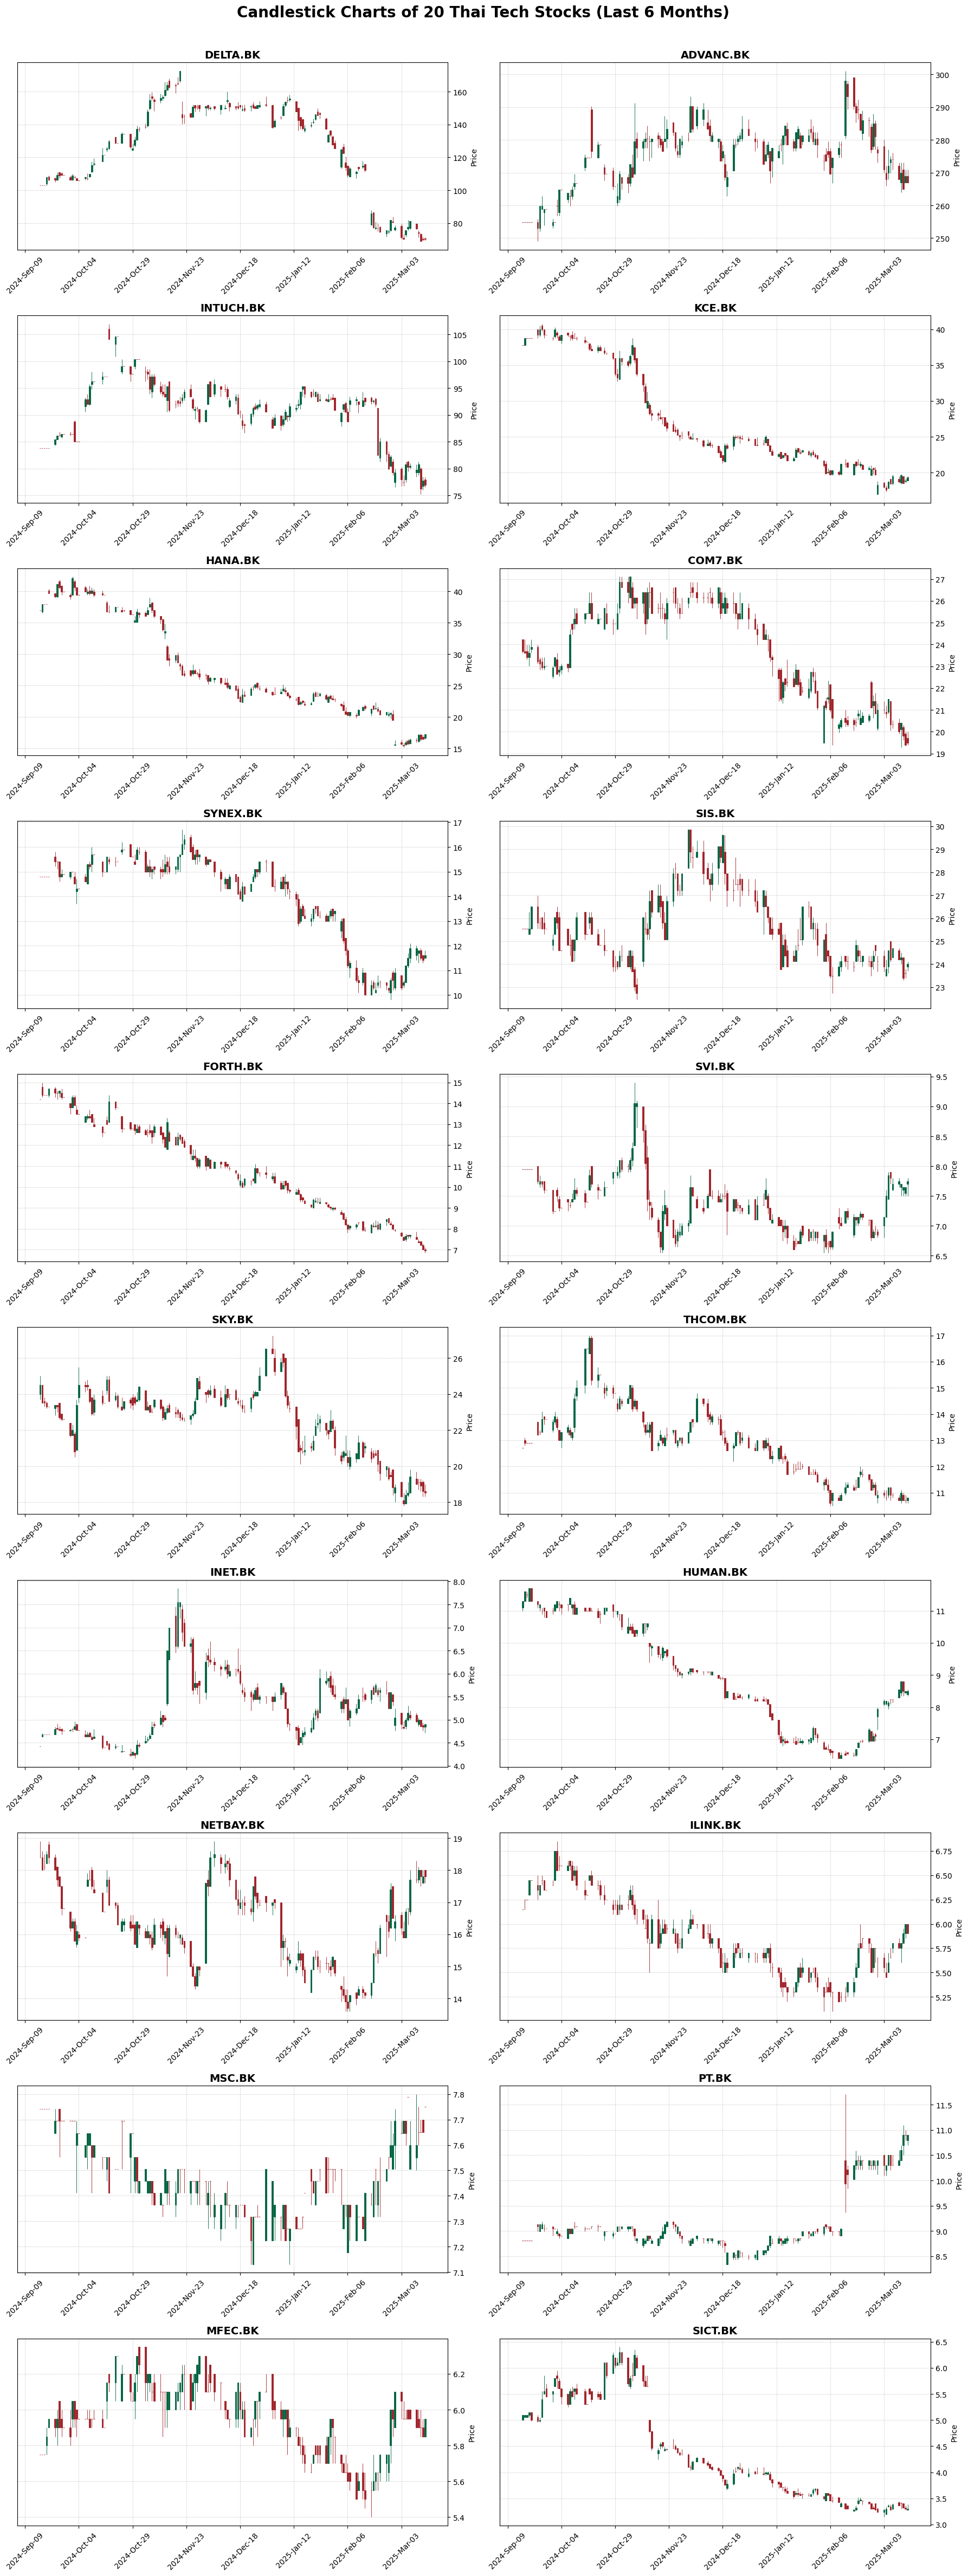

In [18]:
import yfinance as yf
import mplfinance as mpf
import pandas as pd
import matplotlib.pyplot as plt

# 20 Thai Tech Stocks on SET
tickers = [
    "DELTA.BK", "ADVANC.BK", "INTUCH.BK", "KCE.BK", "HANA.BK",
    "COM7.BK", "SYNEX.BK", "SIS.BK", "FORTH.BK", "SVI.BK",
    "SKY.BK", "THCOM.BK", "INET.BK", "HUMAN.BK", "NETBAY.BK",
    "ILINK.BK", "MSC.BK", "PT.BK", "MFEC.BK", "SICT.BK"
]

# Set up a figure with 10 rows × 2 columns (20 subplots)
fig, axes = plt.subplots(nrows=10, ncols=2, figsize=(18, 50))  # Professional aspect ratio
fig.suptitle("Candlestick Charts of 20 Thai Tech Stocks (Last 6 Months)", fontsize=20, fontweight='bold')

# Flatten axes for easier iteration
axes = axes.flatten()
plot_index = 0  # Counter for subplots used

# Define mplfinance style with grid lines
market_style = mpf.make_mpf_style(base_mpf_style='charles', rc={'axes.grid': True})

for ticker in tickers:
    print(f"Processing {ticker} ...")
    try:
        # Fetch data (6 months)
        df = yf.Ticker(ticker).history(period="6mo")

        # Skip if no data is available
        if df.empty:
            print(f"No data for {ticker}, skipping...\n")
            continue

        # Ensure numeric columns
        df = df.apply(pd.to_numeric, errors='coerce')
        df.dropna(subset=["Open", "High", "Low", "Close"], inplace=True)

        if df.empty:
            print(f"Data for {ticker} is empty after cleaning, skipping...\n")
            continue

        # Plot candlestick chart
        mpf.plot(
            df,
            type="candle",
            style=market_style,
            ax=axes[plot_index],
            volume=False,
            show_nontrading=True
        )

        # Enable grid lines for clarity
        axes[plot_index].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

        # Set title and other properties
        axes[plot_index].set_title(ticker, fontsize=14, fontweight='bold')

        plot_index += 1

    except Exception as e:
        print(f"Error for {ticker}: {e}\n")

# Remove any unused subplots to maintain a clean layout
for j in range(plot_index, len(axes)):
    fig.delaxes(axes[j])

# Improve layout spacing
plt.subplots_adjust(hspace=0.4, wspace=0.3)  # Add spacing between plots
plt.tight_layout(rect=[0, 0.03, 1, 0.975])  # Adjust layout for better spacing

plt.show()

#### UI Interface

In [19]:
import yfinance as yf
import mplfinance as mpf
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from datetime import datetime

# List of 20 Thai Tech Stocks on SET
tickers = [
    "DELTA.BK", "ADVANC.BK", "INTUCH.BK", "KCE.BK", "HANA.BK",
    "COM7.BK", "SYNEX.BK", "SIS.BK", "FORTH.BK", "SVI.BK",
    "SKY.BK", "THCOM.BK", "INET.BK", "HUMAN.BK", "NETBAY.BK",
    "ILINK.BK", "MSC.BK", "PT.BK", "MFEC.BK", "SICT.BK"
]

# Function to fetch and plot the candlestick chart
def plot_candlestick_chart(ticker, start_date, end_date):
    try:
        # Fetch data for the selected date range
        df = yf.Ticker(ticker).history(start=start_date, end=end_date)

        # Skip if no data is available
        if df.empty:
            print(f"No valid data for {ticker} in the selected date range, skipping...\n")
            return

        # Ensure numeric columns and drop missing data
        df = df.apply(pd.to_numeric, errors='coerce')
        df.dropna(subset=["Open", "High", "Low", "Close"], inplace=True)

        # Clear previous output
        clear_output(wait=True)

        # Create a new figure for the candlestick chart
        fig, ax = plt.subplots(figsize=(10, 6))

        # Define the style with grid lines
        market_style = mpf.make_mpf_style(base_mpf_style='charles', rc={'axes.grid': True})

        # Plot the candlestick chart
        mpf.plot(df, type="candle", style=market_style, ax=ax, volume=False, show_nontrading=True)

        # Enable grid lines for clarity
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

        # Set the title for the chart
        ax.set_title(f"{ticker} Candlestick Chart", fontsize=14, fontweight='bold')

        # Show the plot in the notebook
        plt.show()

    except Exception as e:
        print(f"Error for {ticker}: {e}")

# Create widgets for selecting stock, start date, and end date
stock_selector = widgets.Dropdown(
    options=tickers,
    value=tickers[0],  # default selection
    description='Stock:',
    disabled=False
)

# Date picker widgets for start and end date
start_date_picker = widgets.DatePicker(
    description='Start Date',
    value=datetime(2023, 1, 1),  # default start date
)

end_date_picker = widgets.DatePicker(
    description='End Date',
    value=datetime(2025, 12, 31),  # default end date
)

# Use widgets.interactive() to ensure dynamic updates
interactive_plot = widgets.interactive(
    plot_candlestick_chart,
    ticker=stock_selector,
    start_date=start_date_picker,
    end_date=end_date_picker
)

# Display the widgets and the interactive plot
display(interactive_plot)


interactive(children=(Dropdown(description='Stock:', options=('DELTA.BK', 'ADVANC.BK', 'INTUCH.BK', 'KCE.BK', …

In [20]:
import yfinance as yf
import mplfinance as mpf
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from datetime import datetime
import numpy as np

# List of 20 Thai Tech Stocks on SET
tickers = [
    "DELTA.BK", "ADVANC.BK", "INTUCH.BK", "KCE.BK", "HANA.BK",
    "COM7.BK", "SYNEX.BK", "SIS.BK", "FORTH.BK", "SVI.BK",
    "SKY.BK", "THCOM.BK", "INET.BK", "HUMAN.BK", "NETBAY.BK",
    "ILINK.BK", "MSC.BK", "PT.BK", "MFEC.BK", "SICT.BK"
]

# Function to calculate Beta
def get_beta(ticker, benchmark='^SET.BK'):
    stock = yf.Ticker(ticker)
    benchmark_data = yf.Ticker(benchmark)

    stock_data = stock.history(period="1y")
    benchmark_data = benchmark_data.history(period="1y")

    stock_returns = stock_data['Close'].pct_change().dropna()
    benchmark_returns = benchmark_data['Close'].pct_change().dropna()

    merged_data = pd.concat([stock_returns, benchmark_returns], axis=1).dropna()
    merged_data.columns = ['Stock', 'Benchmark']

    covariance = np.cov(merged_data['Stock'], merged_data['Benchmark'])[0][1]
    variance = np.var(merged_data['Benchmark'])

    beta = covariance / variance
    return beta

# Function to fetch and plot the candlestick chart
def plot_candlestick_chart(ticker, start_date, end_date):
    try:
        # Fetch data for the selected date range
        df = yf.Ticker(ticker).history(start=start_date, end=end_date)

        # Skip if no data is available
        if df.empty:
            print(f"No valid data for {ticker} in the selected date range, skipping...\n")
            return

        # Ensure numeric columns and drop missing data
        df = df.apply(pd.to_numeric, errors='coerce')
        df.dropna(subset=["Open", "High", "Low", "Close"], inplace=True)

        # Calculate 50-day moving average for Exit Signal
        df['50_MA'] = df['Close'].rolling(window=50).mean()
        df['Exit Signal'] = (df['Close'] < df['50_MA']).astype(int)

        # Get Beta, Sharpe Ratio, Market Share, and other metrics
        beta = get_beta(ticker)
        sharpe_ratio = (df['Close'].pct_change().mean() - 0.03) / df['Close'].pct_change().std()
        market_share = 100  # Example placeholder, you can calculate based on market cap
        exit_signal = df['Exit Signal'].iloc[-1]

        # Clear previous output
        clear_output(wait=True)

        # Create a new figure for the candlestick chart
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 1]})

        # Define the style with grid lines
        market_style = mpf.make_mpf_style(base_mpf_style='charles', rc={'axes.grid': True})

        # Plot the candlestick chart
        mpf.plot(df, type="candle", style=market_style, ax=ax1, volume=False, show_nontrading=True)

        # Dashboard on the right side showing key metrics
        # Displaying Beta, Sharpe Ratio, Market Share, Exit Signal as cards
        ax2.axis('off')
        ax2.text(0.1, 0.9, f"Beta: {beta:.2f}", fontsize=12, ha='left', va='top', fontweight='bold')
        ax2.text(0.1, 0.75, f"Sharpe Ratio: {sharpe_ratio:.2f}", fontsize=12, ha='left', va='top', fontweight='bold')
        ax2.text(0.1, 0.6, f"Market Share: {market_share:.2f}%", fontsize=12, ha='left', va='top', fontweight='bold')
        ax2.text(0.1, 0.45, f"Exit Signal: {exit_signal}", fontsize=12, ha='left', va='top', fontweight='bold')

        # Adding labels for clarity
        ax2.text(0.1, 1.05, "Stock Metrics:", fontsize=14, ha='left', fontweight='bold')

        # Show the plot
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error for {ticker}: {e}")

# Create widgets for selecting stock, start date, and end date
stock_selector = widgets.Dropdown(
    options=tickers,
    value=tickers[0],  # default selection
    description='Stock:',
    disabled=False
)

# Date picker widgets for start and end date
start_date_picker = widgets.DatePicker(
    description='Start Date',
    value=datetime(2023, 1, 1),  # default start date
)

end_date_picker = widgets.DatePicker(
    description='End Date',
    value=datetime(2025, 12, 31),  # default end date
)

# Use widgets.interactive() to ensure dynamic updates
interactive_plot = widgets.interactive(
    plot_candlestick_chart,
    ticker=stock_selector,
    start_date=start_date_picker,
    end_date=end_date_picker
)

# Display the widgets and the interactive plot
display(interactive_plot)


interactive(children=(Dropdown(description='Stock:', options=('DELTA.BK', 'ADVANC.BK', 'INTUCH.BK', 'KCE.BK', …

In [ ]:
import yfinance as yf
import mplfinance as mpf
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from datetime import datetime
import numpy as np

# List of 20 Thai Tech Stocks on SET
tickers = [
    "DELTA.BK", "ADVANC.BK", "INTUCH.BK", "KCE.BK", "HANA.BK",
    "COM7.BK", "SYNEX.BK", "SIS.BK", "FORTH.BK", "SVI.BK",
    "SKY.BK", "THCOM.BK", "INET.BK", "HUMAN.BK", "NETBAY.BK",
    "ILINK.BK", "MSC.BK", "PT.BK", "MFEC.BK", "SICT.BK"
]

# Function to calculate Beta
def get_beta(ticker, benchmark='^SET.BK'):
    stock = yf.Ticker(ticker)
    benchmark_data = yf.Ticker(benchmark)

    stock_data = stock.history(period="1y")
    benchmark_data = benchmark_data.history(period="1y")

    stock_returns = stock_data['Close'].pct_change().dropna()
    benchmark_returns = benchmark_data['Close'].pct_change().dropna()

    merged_data = pd.concat([stock_returns, benchmark_returns], axis=1).dropna()
    merged_data.columns = ['Stock', 'Benchmark']

    covariance = np.cov(merged_data['Stock'], merged_data['Benchmark'])[0][1]
    variance = np.var(merged_data['Benchmark'])

    beta = covariance / variance
    return beta


# Function to fetch and plot the candlestick chart
def plot_candlestick_chart(ticker, start_date, end_date, risk_free_rate):
    try:
        # Fetch data for the selected date range
        df = yf.Ticker(ticker).history(start=start_date, end=end_date)

        # Skip if no data is available
        if df.empty:
            print(f"No valid data for {ticker} in the selected date range, skipping...\n")
            return

        # Ensure numeric columns and drop missing data
        df = df.apply(pd.to_numeric, errors='coerce')
        df.dropna(subset=["Open", "High", "Low", "Close"], inplace=True)

        # Calculate 50-day moving average for Exit Signal
        df['50_MA'] = df['Close'].rolling(window=50).mean()
        df['Exit Signal'] = (df['Close'] < df['50_MA']).astype(int)

        # Convert Exit Signal to text (STAY = 1, EXIT = 0)
        df['Exit Signal'] = df['Exit Signal'].map({1: "EXIT", 0: "STAY"})

        # Get Beta, Sharpe Ratio, Market Share, and other metrics
        beta = get_beta(ticker)
        sharpe_ratio = (df['Close'].pct_change().mean() - risk_free_rate) / df['Close'].pct_change().std()
        market_share = 100  # Example placeholder, you can calculate based on market cap
        exit_signal = df['Exit Signal'].iloc[-1]

        # Clear previous output
        clear_output(wait=True)

        # Create a new figure for the candlestick chart
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 1]})

        # Define the style with grid lines
        market_style = mpf.make_mpf_style(base_mpf_style='charles', rc={'axes.grid': True})

        # Plot the candlestick chart
        mpf.plot(df, type="candle", style=market_style, ax=ax1, volume=False, show_nontrading=True, mav=(50))

        # Dashboard on the right side showing key metrics
        # Displaying Beta, Sharpe Ratio, Market Share, Exit Signal as cards
        ax2.axis('off')
        ax2.text(0.1, 0.9, f"Beta: {beta:.2f}", fontsize=12, ha='left', va='top', fontweight='bold')
        ax2.text(0.1, 0.75, f"Sharpe Ratio: {sharpe_ratio:.2f}", fontsize=12, ha='left', va='top', fontweight='bold')
        ax2.text(0.1, 0.6, f"Market Share: {market_share:.2f}%", fontsize=12, ha='left', va='top', fontweight='bold')
        ax2.text(0.1, 0.45, f"Exit Signal: {exit_signal}", fontsize=12, ha='left', va='top', fontweight='bold')

        # Adding labels for clarity
        ax2.text(0.1, 1.05, "Stock Metrics:", fontsize=14, ha='left', fontweight='bold')

        # Show the plot
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error for {ticker}: {e}")

# Create widgets for selecting stock, start date, and end date
stock_selector = widgets.Dropdown(
    options=tickers,
    value=tickers[0],  # default selection
    description='Stock:',
    disabled=False
)

# Date picker widgets for start and end date
start_date_picker = widgets.DatePicker(
    description='Start Date',
    value=datetime(2023, 1, 1),  # default start date
)

end_date_picker = widgets.DatePicker(
    description='End Date',
    value=datetime(2025, 12, 31),  # default end date
)

# Widget to input custom risk-free rate
risk_free_rate_slider = widgets.FloatSlider(
    value=0.03,  # default value for the risk-free rate
    min=0,
    max=0.1,
    step=0.001,
    description='Risk-Free Rate:',
    style={'description_width': 'initial'}
)

# Use widgets.interactive() to ensure dynamic updates
interactive_plot = widgets.interactive(
    plot_candlestick_chart,
    ticker=stock_selector,
    start_date=start_date_picker,
    end_date=end_date_picker,
    risk_free_rate=risk_free_rate_slider
)

# Display the widgets and the interactive plot
display(interactive_plot)

interactive(children=(Dropdown(description='Stock:', options=('DELTA.BK', 'ADVANC.BK', 'INTUCH.BK', 'KCE.BK', …

In [ ]:
import yfinance as yf
import mplfinance as mpf
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from datetime import datetime
import numpy as np

#########################################
# 1) FETCH MARKET CAP & CALCULATE MARKET SHARE
#########################################

# List of Thai Tech Stocks
tickers = [
    "DELTA.BK", "ADVANC.BK", "INTUCH.BK", "KCE.BK", "HANA.BK",
    "COM7.BK", "SYNEX.BK", "SIS.BK", "FORTH.BK", "SVI.BK",
    "SKY.BK", "THCOM.BK", "INET.BK", "HUMAN.BK", "NETBAY.BK",
    "ILINK.BK", "MSC.BK", "PT.BK", "MFEC.BK", "SICT.BK"
]

# Function to fetch market capitalization
def get_market_cap(ticker):
    stock = yf.Ticker(ticker)
    return stock.info.get('marketCap', np.nan)  # Return market cap or NaN if missing

# Fetch market caps and compute total market capitalization
market_caps = {ticker: get_market_cap(ticker) for ticker in tickers}
total_market_cap = sum(cap for cap in market_caps.values() if not np.isnan(cap))  # Sum only valid values

#########################################
# 2) FUNCTION TO FETCH BETA
#########################################

def get_beta(ticker, benchmark='^SET.BK'):
    stock = yf.Ticker(ticker)
    benchmark_data = yf.Ticker(benchmark)

    stock_data = stock.history(period="1y")
    benchmark_data = benchmark_data.history(period="1y")

    stock_returns = stock_data['Close'].pct_change().dropna()
    benchmark_returns = benchmark_data['Close'].pct_change().dropna()

    merged_data = pd.concat([stock_returns, benchmark_returns], axis=1).dropna()
    merged_data.columns = ['Stock', 'Benchmark']

    covariance = np.cov(merged_data['Stock'], merged_data['Benchmark'])[0][1]
    variance = np.var(merged_data['Benchmark'])

    return covariance / variance

#########################################
# 3) FUNCTION TO FETCH DATA & PLOT CANDLESTICK CHART
#########################################

def plot_candlestick_chart(ticker, start_date, end_date, risk_free_rate):
    try:
        # Fetch stock data
        df = yf.Ticker(ticker).history(start=start_date, end=end_date)

        if df.empty:
            print(f"No valid data for {ticker} in the selected date range.")
            return

        # Ensure numeric columns and drop missing data
        df = df.apply(pd.to_numeric, errors='coerce')
        df.dropna(subset=["Open", "High", "Low", "Close"], inplace=True)

        # Calculate 50-day moving average
        df['50_MA'] = df['Close'].rolling(window=50).mean()
        df['Exit Signal'] = (df['Close'] < df['50_MA']).astype(int)

        # Convert Exit Signal to text (1 = STAY, 0 = EXIT)
        df['Exit Signal'] = df['Exit Signal'].map({1: "EXIT", 0: "STAY"})

        # Get Beta and Sharpe Ratio
        beta = get_beta(ticker)
        sharpe_ratio = (df['Close'].pct_change().mean() - risk_free_rate) / df['Close'].pct_change().std()

        # Get Market Share (avoid division errors)
        market_cap = market_caps.get(ticker, np.nan)
        market_share = (market_cap / total_market_cap) * 100 if not np.isnan(market_cap) else np.nan

        # Get latest Exit Signal
        exit_signal = df['Exit Signal'].iloc[-1]

        # Clear previous output
        clear_output(wait=True)

        # Create a figure with two subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 1]})

        # Define candlestick style
        market_style = mpf.make_mpf_style(base_mpf_style='charles', rc={'axes.grid': True})

        # Plot candlestick chart
        mpf.plot(df, type="candle", style=market_style, ax=ax1, volume=False, show_nontrading=True, mav=(50,100))
    

        # Display stock metrics on the right panel
        ax2.axis('off')
        ax2.text(0.1, 0.9, f"Beta: {beta:.2f}", fontsize=12, ha='left', va='top', fontweight='bold')
        ax2.text(0.1, 0.75, f"Sharpe Ratio: {sharpe_ratio:.2f}", fontsize=12, ha='left', va='top', fontweight='bold')

        if not np.isnan(market_share):
            ax2.text(0.1, 0.6, f"Market Share: {market_share:.2f}%", fontsize=12, ha='left', va='top', fontweight='bold')
        else:
            ax2.text(0.1, 0.6, "Market Share: Data Missing", fontsize=12, ha='left', va='top', fontweight='bold', color='red')

        ax2.text(0.1, 0.45, f"Exit Signal: {exit_signal}", fontsize=12, ha='left', va='top', fontweight='bold')

        ax2.text(0.1, 1.05, "Stock Metrics:", fontsize=14, ha='left', fontweight='bold')

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error for {ticker}: {e}")

#########################################
# 4) CREATE UI WIDGETS
#########################################

# Dropdown to select a stock
stock_selector = widgets.Dropdown(
    options=tickers,
    value=tickers[0],  
    description='Stock:',
    disabled=False
)

# Date picker widgets
start_date_picker = widgets.DatePicker(
    description='Start Date',
    value=datetime(2023, 1, 1),  
)

end_date_picker = widgets.DatePicker(
    description='End Date',
    value=datetime(2025, 12, 31),
)

# Risk-Free Rate Slider
risk_free_rate_slider = widgets.FloatSlider(
    value=0.03,  # Default: 3%
    min=0,
    max=0.1,
    step=0.001,
    description='Risk-Free Rate:',
    style={'description_width': 'initial'}
)

# Use widgets.interactive() to ensure dynamic updates
interactive_plot = widgets.interactive(
    plot_candlestick_chart,
    ticker=stock_selector,
    start_date=start_date_picker,
    end_date=end_date_picker,
    risk_free_rate=risk_free_rate_slider
)

# Display widgets and interactive plot
display(interactive_plot)

interactive(children=(Dropdown(description='Stock:', options=('DELTA.BK', 'ADVANC.BK', 'INTUCH.BK', 'KCE.BK', …

In [ ]:
import yfinance as yf
import mplfinance as mpf
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from datetime import datetime
import numpy as np

#########################################
# 1) FETCH MARKET CAP & CALCULATE MARKET SHARE
#########################################

# List of Thai Tech Stocks
tickers = [
    "DELTA.BK", "ADVANC.BK", "INTUCH.BK", "KCE.BK", "HANA.BK",
    "COM7.BK", "SYNEX.BK", "SIS.BK", "FORTH.BK", "SVI.BK",
    "SKY.BK", "THCOM.BK", "INET.BK", "HUMAN.BK", "NETBAY.BK",
    "ILINK.BK", "MSC.BK", "PT.BK", "MFEC.BK", "SICT.BK"
]

# Function to fetch market capitalization
def get_market_cap(ticker):
    stock = yf.Ticker(ticker)
    return stock.info.get('marketCap', np.nan)  # Return market cap or NaN if missing

# Fetch market caps and compute total market capitalization
market_caps = {ticker: get_market_cap(ticker) for ticker in tickers}
total_market_cap = sum(cap for cap in market_caps.values() if not np.isnan(cap))  # Sum only valid values

#########################################
# 2) FUNCTION TO FETCH BETA
#########################################

def get_beta(ticker, benchmark='^SET.BK'):
    stock = yf.Ticker(ticker)
    benchmark_data = yf.Ticker(benchmark)

    stock_data = stock.history(period="1y")
    benchmark_data = benchmark_data.history(period="1y")

    stock_returns = stock_data['Close'].pct_change().dropna()
    benchmark_returns = benchmark_data['Close'].pct_change().dropna()

    merged_data = pd.concat([stock_returns, benchmark_returns], axis=1).dropna()
    merged_data.columns = ['Stock', 'Benchmark']

    covariance = np.cov(merged_data['Stock'], merged_data['Benchmark'])[0][1]
    variance = np.var(merged_data['Benchmark'])

    return covariance / variance

#########################################
# 3) FUNCTION TO FETCH DATA & PLOT CANDLESTICK CHART
#########################################

def plot_candlestick_chart(ticker, start_date, end_date, risk_free_rate):
    try:
        # Fetch stock data
        df = yf.Ticker(ticker).history(start=start_date, end=end_date)

        if df.empty:
            print(f"No valid data for {ticker} in the selected date range.")
            return

        # Ensure numeric columns and drop missing data
        df = df.apply(pd.to_numeric, errors='coerce')
        df.dropna(subset=["Open", "High", "Low", "Close"], inplace=True)

        # Calculate moving averages and exit signal
        df['50_MA'] = df['Close'].rolling(window=50).mean()
        df['100_MA'] = df['Close'].rolling(window=100).mean()
        df['Exit Signal'] = (df['Close'] < df['50_MA']).astype(int)

        # Convert Exit Signal to text (1 = STAY, 0 = EXIT)
        df['Exit Signal'] = df['Exit Signal'].map({1: "EXIT", 0: "STAY"})

        # Get Beta and Sharpe Ratio
        beta = get_beta(ticker)
        sharpe_ratio = (df['Close'].pct_change().mean() - risk_free_rate) / df['Close'].pct_change().std()

        # Get Market Share (avoid division errors)
        market_cap = market_caps.get(ticker, np.nan)
        market_share = (market_cap / total_market_cap) * 100 if not np.isnan(market_cap) else np.nan

        # Get latest Exit Signal
        exit_signal = df['Exit Signal'].iloc[-1]

        # Clear previous output
        clear_output(wait=True)

        # Create **Figure Layout** (Chart + Volume + Metrics)
        fig, axes = plt.subplots(2, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [4, 1], 'height_ratios': [3, 1]})
        fig.subplots_adjust(hspace=0.05, wspace=0.3)  # Adjust spacing

        # Define candlestick style
        market_style = mpf.make_mpf_style(base_mpf_style='charles', rc={'axes.grid': True})

        # Plot candlestick chart with volume
        mpf.plot(
            df, type="candle", style=market_style,
            ax=axes[0, 0], volume=axes[1, 0], show_nontrading=True, mav=(50)
        )

        # Create **right-side panel** for metrics
        ax_right = axes[0, 1]  # Assign right subplot
        ax_right.axis('off')  # Hide axis

        # Display Stock Metrics in Right Panel
        ax_right.text(0.1, 0.9, f"**{ticker} Metrics**", fontsize=14, ha='left', fontweight='bold')
        ax_right.text(0.1, 0.75, f"Beta: {beta:.2f}", fontsize=12, ha='left', va='top', fontweight='bold')
        ax_right.text(0.1, 0.6, f"Sharpe Ratio: {sharpe_ratio:.2f}", fontsize=12, ha='left', va='top', fontweight='bold')

        if not np.isnan(market_share):
            ax_right.text(0.1, 0.45, f"Market Share: {market_share:.2f}%", fontsize=12, ha='left', va='top', fontweight='bold')
        else:
            ax_right.text(0.1, 0.45, "Market Share: Data Missing", fontsize=12, ha='left', va='top', fontweight='bold', color='red')

        ax_right.text(0.1, 0.3, f"Exit Signal: {exit_signal}", fontsize=12, ha='left', va='top', fontweight='bold')

        # Hide bottom right panel (not used)
        axes[1, 1].axis('off')

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error for {ticker}: {e}")

#########################################
# 4) CREATE UI WIDGETS
#########################################

# Dropdown to select a stock
stock_selector = widgets.Dropdown(
    options=tickers,
    value=tickers[0],  
    description='Stock:',
    disabled=False
)

# Date picker widgets
start_date_picker = widgets.DatePicker(
    description='Start Date',
    value=datetime(2023, 1, 1),  
)

end_date_picker = widgets.DatePicker(
    description='End Date',
    value=datetime(2025, 12, 31),
)

# Risk-Free Rate Slider
risk_free_rate_slider = widgets.FloatSlider(
    value=0.03,  # Default: 3%
    min=0,
    max=0.1,
    step=0.001,
    description='Risk-Free Rate:',
    style={'description_width': 'initial'}
)

# Use widgets.interactive() to ensure dynamic updates
interactive_plot = widgets.interactive(
    plot_candlestick_chart,
    ticker=stock_selector,
    start_date=start_date_picker,
    end_date=end_date_picker,
    risk_free_rate=risk_free_rate_slider
)

# Display widgets and interactive plot
display(interactive_plot)

interactive(children=(Dropdown(description='Stock:', options=('DELTA.BK', 'ADVANC.BK', 'INTUCH.BK', 'KCE.BK', …

### 📊 Beta, Sharpe Ratio, and Exit Signal Analysis for SET Technology Stocks


📊 **Key Financial Metrics: Beta, Sharpe Ratio, and Market Share**

🔹 **Beta (β) - Measuring Stock Volatility**
**Definition:**
- Beta is a measure of a stock's **volatility** or **systematic risk** in relation to the overall market (e.g., S&P 500 or SET Index).
- It indicates how much the stock's price moves **relative** to the market.

**Formula:**

**$
\beta = \frac{\text{Covariance of the Stock with the Market}}{\text{Variance of the Market}}
$**


**Interpretation:**
- **β = 1** → The stock **moves in line** with the market.
- **β > 1** → The stock is **more volatile** than the market.
- **β < 1** → The stock is **less volatile** than the market.
- **β < 0** → The stock **moves in the opposite direction** of the market (e.g., gold stocks during a market crash).


🔹 **Sharpe Ratio (S) - Risk-Adjusted Return**
**Definition:**
- The Sharpe ratio measures the **return of an investment compared to its risk** (volatility).
- It helps determine whether an investment is **worth the risk taken**.

**Formula:**

$
\text{Sharpe Ratio} = \frac{\text{Average Return of the Asset} - \text{Risk-Free Rate}}{\text{Standard Deviation of Asset’s Returns}}
$

**Interpretation:**
- **Sharpe Ratio > 1** → **Good** risk-adjusted return.
- **Sharpe Ratio = 1** → **Acceptable** return relative to risk.
- **Sharpe Ratio < 1** → **Poor** return for the risk taken.

---

🔹 **Market Share Calculation**
**1. Market Capitalization:**

$
\text{Market Cap} = \text{Stock Price} \times \text{Shares Outstanding}
$

- Represents the total **value of a company** in the stock market.

**2. Sector Market Capitalization:**

$
\text{Total Market Cap of Sector} = \sum \text{Market Cap of all stocks in the sector}
$

- Sum of market caps for all **20 technology stocks** provided.

**3. Market Share Calculation:**

$
\text{Market Share of Stock} = \left( \frac{\text{Market Cap of Stock}}{\text{Total Market Cap of Sector}} \right) \times 100
$

- This provides the **percentage of the sector’s market cap** represented by each stock.

📌 **Conclusion:**
- **Beta helps measure risk**, indicating how much a stock moves compared to the market.
- **Sharpe ratio helps investors understand risk-adjusted returns**, ensuring they take on appropriate levels of risk.
- **Market share analysis** shows which stocks dominate the sector in terms of market capitalization.

Processing DELTA.BK...
Processing ADVANC.BK...
Processing INTUCH.BK...
Processing KCE.BK...
Processing HANA.BK...
Processing COM7.BK...
Processing SYNEX.BK...
Processing SIS.BK...
Processing FORTH.BK...
Processing SVI.BK...
Processing SKY.BK...
Processing THCOM.BK...
Processing INET.BK...
Processing HUMAN.BK...
Processing NETBAY.BK...
Processing ILINK.BK...
Processing MSC.BK...
Processing PT.BK...
Processing MFEC.BK...
Processing SICT.BK...


,Stock,Beta,Sharpe Ratio,P/E Ratio,P/B Ratio,Dividend Yield,ROE,Market Share,Exit Signal
0,DELTA.BK,1.81,-0.85,46.22,10.96,0.66,0.26,41.83,1
1,ADVANC.BK,0.82,-1.96,22.67,8.17,4.27,0.37,37.90,1
2,INTUCH.BK,1.07,-1.51,18.33,5.97,5.14,0.33,11.79,1
3,KCE.BK,1.25,-1.31,13.88,1.66,6.35,0.12,1.09,1
4,HANA.BK,1.32,-1.11,NaN,0.57,4.55,-0.02,0.73,1
5,COM7.BK,0.99,-1.38,14.03,5.31,4.43,0.39,2.19,1
6,SYNEX.BK,1.09,-1.00,15.68,2.21,2.98,0.15,0.47,1
7,SIS.BK,1.09,-1.00,12.06,2.05,4.75,0.18,0.40,1
8,FORTH.BK,1.39,-0.96,28.96,3.35,4.29,0.14,0.31,1
9,SVI.BK,0.69,-1.02,12.11,2.18,3.14,0.19,0.80,0


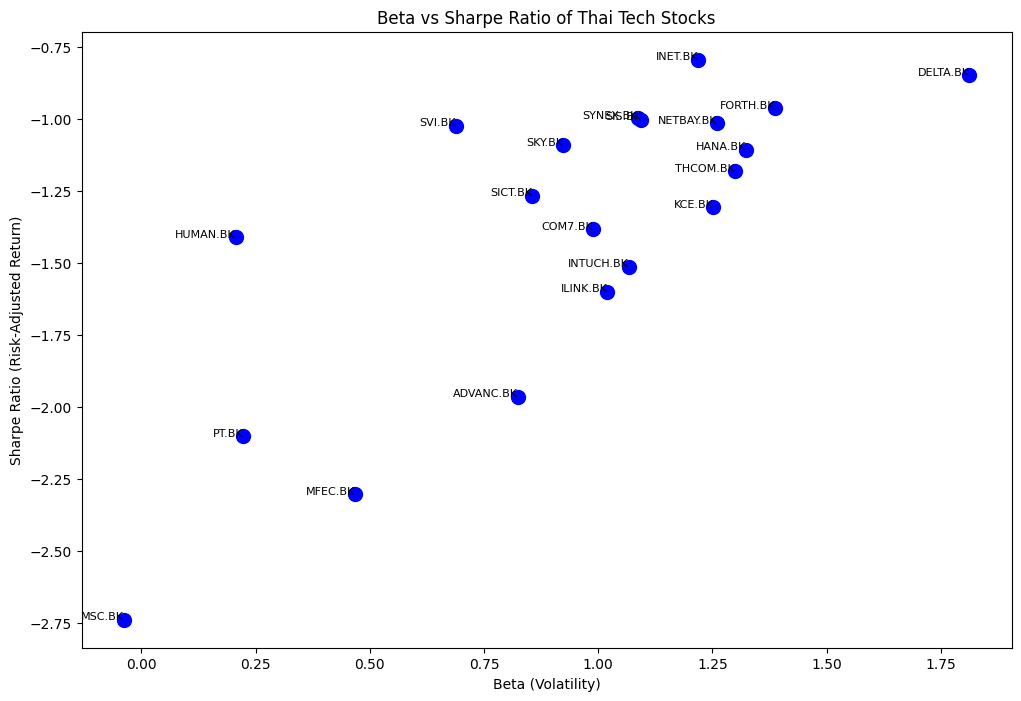

In [24]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# List of 20 Thai Tech Stocks on SET
tickers = [
    "DELTA.BK", "ADVANC.BK", "INTUCH.BK", "KCE.BK", "HANA.BK",
    "COM7.BK", "SYNEX.BK", "SIS.BK", "FORTH.BK", "SVI.BK",
    "SKY.BK", "THCOM.BK", "INET.BK", "HUMAN.BK", "NETBAY.BK",
    "ILINK.BK", "MSC.BK", "PT.BK", "MFEC.BK", "SICT.BK"
]

# Define the risk-free rate (can be updated with a more accurate value if needed)
risk_free_rate = 0.03  # Example: 3% as the risk-free rate

# Function to fetch the market capitalization
def get_market_cap(ticker):
    stock = yf.Ticker(ticker)
    # Get the market capitalization
    market_cap = stock.info.get('marketCap', np.nan)
    return market_cap

# Function to calculate Beta
def get_beta(ticker, benchmark='^SET.BK'):
    stock = yf.Ticker(ticker)
    benchmark_data = yf.Ticker(benchmark)

    stock_data = stock.history(period="1y")
    benchmark_data = benchmark_data.history(period="1y")

    stock_returns = stock_data['Close'].pct_change().dropna()
    benchmark_returns = benchmark_data['Close'].pct_change().dropna()

    merged_data = pd.concat([stock_returns, benchmark_returns], axis=1).dropna()
    merged_data.columns = ['Stock', 'Benchmark']

    covariance = np.cov(merged_data['Stock'], merged_data['Benchmark'])[0][1]
    variance = np.var(merged_data['Benchmark'])

    beta = covariance / variance
    return beta

# Function to calculate Sharpe Ratio
def get_sharpe_ratio(ticker):
    stock = yf.Ticker(ticker)

    stock_data = stock.history(period="1y")

    daily_returns = stock_data['Close'].pct_change().dropna()

    avg_return = daily_returns.mean()
    std_dev = daily_returns.std()

    sharpe_ratio = (avg_return - risk_free_rate) / std_dev
    return sharpe_ratio

# Function to get fundamental metrics (P/E, P/B, Dividend Yield, ROE)
def get_fundamental_data(ticker):
    stock = yf.Ticker(ticker)
    info = stock.info

    pe_ratio = info.get('trailingPE', np.nan)
    pb_ratio = info.get('priceToBook', np.nan)
    dividend_yield = info.get('dividendYield', np.nan)
    roe = info.get('returnOnEquity', np.nan)

    return pe_ratio, pb_ratio, dividend_yield, roe

# Function to calculate exit signal (using moving averages)
def get_exit_signal(ticker):
    stock = yf.Ticker(ticker)

    stock_data = stock.history(period="1y")

    stock_data['50_MA'] = stock_data['Close'].rolling(window=50).mean()
    stock_data['200_MA'] = stock_data['Close'].rolling(window=200).mean()

    if stock_data['Close'].iloc[-1] < stock_data['50_MA'].iloc[-1]:
        exit_signal = 1
    else:
        exit_signal = 0

    return exit_signal

# Collect data for all stocks
stock_data = []

# Fetch market capitalization for each stock
market_caps = []
for ticker in tickers:
    market_caps.append(get_market_cap(ticker))

# Calculate total market capitalization of all stocks (sector market cap)
total_market_cap = sum(market_caps)

# Now get data for each stock and append results
for i, ticker in enumerate(tickers):
    print(f"Processing {ticker}...")

    # Get Beta
    beta = get_beta(ticker)

    # Get Sharpe Ratio
    sharpe_ratio = get_sharpe_ratio(ticker)

    # Get fundamental data (P/E, P/B, Dividend Yield, ROE)
    pe_ratio, pb_ratio, dividend_yield, roe = get_fundamental_data(ticker)

    # Get Exit Signal
    exit_signal = get_exit_signal(ticker)

    # Calculate Market Share
    market_cap = market_caps[i]
    market_share = (market_cap / total_market_cap) * 100  # Market Share in percentage

    # Collect all data for this stock
    stock_data.append({
        'Stock': ticker,
        'Beta': beta,
        'Sharpe Ratio': sharpe_ratio,
        'P/E Ratio': pe_ratio,
        'P/B Ratio': pb_ratio,
        'Dividend Yield': dividend_yield,
        'ROE': roe,
        'Market Share': market_share,
        'Exit Signal': exit_signal
    })

# Convert data to DataFrame for easier comparison
df = pd.DataFrame(stock_data)

# Display the DataFrame with all metrics in a row
pd.set_option('display.float_format', '{:,.2f}'.format)  # To display float values with two decimal places
display(df)

# Plot Variance vs Return (Beta vs Sharpe Ratio)
fig, ax = plt.subplots(figsize=(12, 8))

# Plot Beta vs Sharpe Ratio
ax.scatter(df['Beta'], df['Sharpe Ratio'], color='blue', s=100)
for i, txt in enumerate(df['Stock']):
    ax.annotate(txt, (df['Beta'][i], df['Sharpe Ratio'][i]), fontsize=8, ha='right')

ax.set_xlabel('Beta (Volatility)')
ax.set_ylabel('Sharpe Ratio (Risk-Adjusted Return)')
ax.set_title('Beta vs Sharpe Ratio of Thai Tech Stocks')

plt.show()


#### 🔹 **Beta: Measuring Stock Volatility**
- **Beta measures the volatility of a stock relative to the market (SET index).**
  - **Beta > 1** → The stock is **more volatile** than the market.
  - **Beta < 1** → The stock is **less volatile** than the market.
  - **Negative Beta** → The stock **moves in the opposite direction** of the market (rare).

🔍 **Key Beta Insights**
- **DELTA.BK** has the **highest Beta (1.82)** → **Most volatile stock** compared to the market.
- **HUMAN.BK (0.21) and PT.BK (0.22)** have the **lowest Beta** → **Least volatile stocks**.
- **MSC.BK has a negative Beta**, indicating it moves in the **opposite direction of the market**.



#### 🔹 **Sharpe Ratio: Risk-Adjusted Return**
- **Sharpe Ratio Formula:**
  \[
  \text{Sharpe Ratio} = \frac{\text{Stock Return} - \text{Risk-Free Rate}}{\text{Volatility (Std Dev)}}
  \]
- **Positive Sharpe Ratio** → The stock’s return **justifies its risk**.
- **Negative Sharpe Ratio** → The stock **does not justify its risk** (underperforms risk-free rate).

🔍 **Key Sharpe Ratio Insights**
- **All stocks have negative Sharpe ratios**, meaning **none of these stocks have outperformed the risk-free rate on a risk-adjusted basis**.
- **DELTA.BK has the least negative Sharpe ratio (-0.85)** → **Performs relatively better than others**.
- **MSC.BK has the worst Sharpe ratio (-2.75)** → **Worst risk-adjusted return**.


#### 🔹 **Exit Signal: Moving Average Strategy**
- **Exit Signal = 1** → **Sell Signal** (Stock price is below the 50-day moving average).
- **Exit Signal = 0** → **No Exit Signal** (Stock is holding above the 50-day moving average).

🔍 **Key Exit Signal Insights**
- **Stocks with Exit Signal = 1 (Sell Recommended):**
  - **DELTA.BK, ADVANC.BK, INTUCH.BK, KCE.BK, HANA.BK, COM7.BK, SYNEX.BK, SIS.BK, FORTH.BK, SKY.BK, THCOM.BK, INET.BK, and SICT.BK.**
  
- **Stocks with Exit Signal = 0 (No Sell Signal):**
  - **SVI.BK, HUMAN.BK, NETBAY.BK, ILINK.BK, MSC.BK, PT.BK, and MFEC.BK.**

---

📌 **Summary & Recommendations**
✅ **High Beta stocks** like **DELTA.BK** are **more volatile** and offer **higher potential returns** but come with **greater risk**. **Not ideal for risk-averse investors**.  
✅ **Low Beta stocks** like **HUMAN.BK and PT.BK** are **less volatile**, making them **suitable for conservative investors**.  
✅ **Negative Sharpe ratios** suggest **none of these stocks currently provide favorable risk-adjusted returns** compared to the **risk-free rate**.  
✅ **Most stocks have an Exit Signal = 1**, indicating that **they should be sold based on the moving average strategy**, except for **SVI.BK, HUMAN.BK, and NETBAY.BK**, which are holding their price levels.  

🚀 **Investment Strategy:**  
- **Risk-tolerant investors** can consider **high-beta stocks like DELTA.BK** for **potential short-term gains**.  
- **Risk-averse investors** should focus on **low-beta stocks like HUMAN.BK and PT.BK** for **stability**.  
- **Monitor exit signals carefully** to **adjust positions accordingly** based on market trends.

### Predict Exit Signal

Processing AOT.BK...
Processing ADVANC.BK...
Processing AMATA.BK...
Processing AP.BK...
Processing BANPU.BK...
Processing BBL.BK...
Processing BEM.BK...
Processing BH.BK...
Processing BTS.BK...
Processing CPF.BK...
Processing CPALL.BK...
Processing CRC.BK...
Processing EGCO.BK...
Processing GFPT.BK...
Processing HMPRO.BK...
Processing INTUCH.BK...
Processing IVL.BK...
Processing KBANK.BK...
Processing KCE.BK...
Processing MINT.BK...
Processing MTC.BK...
Processing OSP.BK...
Processing PTT.BK...
Processing PTTEP.BK...
Processing PTTGC.BK...
Processing RATCH.BK...
Processing SCB.BK...
Processing SCC.BK...
Processing TISCO.BK...
Processing TRUE.BK...
Processing TOP.BK...
Processing VGI.BK...
Processing WHART.BK...


,Stock,Beta,Sharpe Ratio,P/E Ratio,P/B Ratio,Dividend Yield,ROE,Market Share,Exit Signal
0,AOT.BK,0.83,-1.93,28.78,4.41,2.01,0.16,8.53,1
1,ADVANC.BK,0.82,-1.96,22.67,8.17,4.27,0.37,11.86,1
2,AMATA.BK,0.96,-1.47,10.14,1.15,3.67,0.13,0.38,1
3,AP.BK,0.92,-1.68,5.44,0.63,6.94,0.12,0.41,0
4,BANPU.BK,1.24,-1.24,NaN,13.19,5.66,0.02,0.66,1
5,BBL.BK,0.46,-2.57,6.14,0.50,4.44,0.08,4.15,1
6,BEM.BK,0.63,-2.08,22.20,2.27,2.75,0.10,1.24,1
7,BH.BK,0.61,-1.63,19.64,5.09,2.89,0.30,2.09,1
8,BTS.BK,1.00,-1.13,34.69,1.50,NaN,0.02,1.33,1
9,CPF.BK,0.80,-1.63,10.08,0.91,4.60,0.08,2.79,0


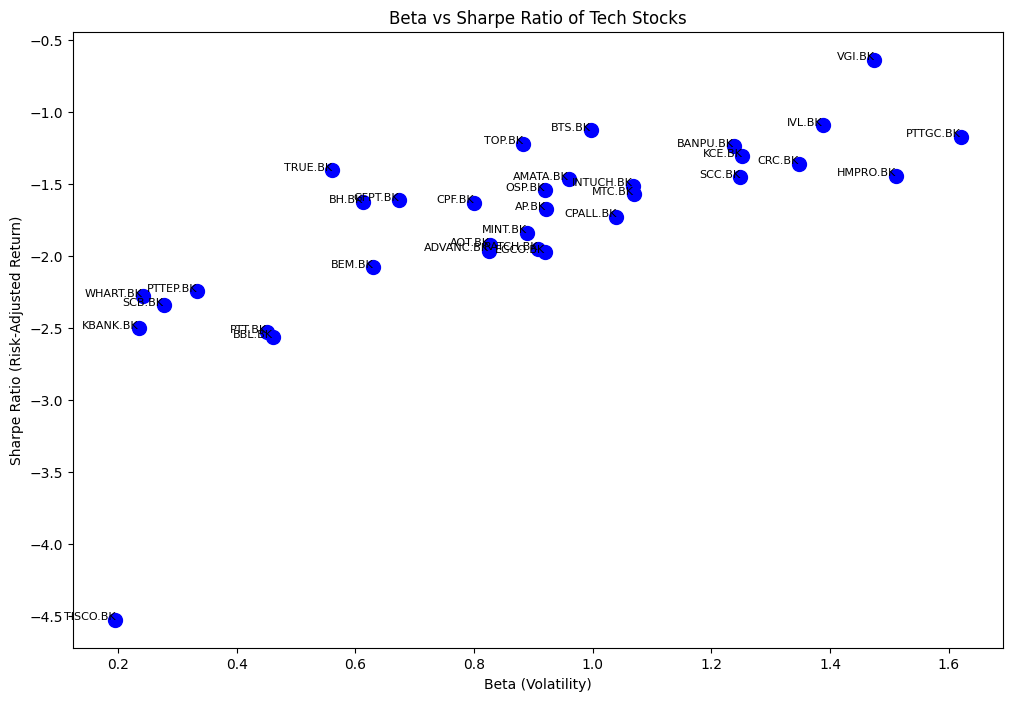

In [25]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Updated list of valid tickers
tickers = [
    "AOT.BK", "ADVANC.BK", "AMATA.BK", "AP.BK", "BANPU.BK",
    "BBL.BK", "BEM.BK", "BH.BK",  "BTS.BK",
    "CPF.BK", "CPALL.BK", "CRC.BK", "EGCO.BK",
    "GFPT.BK", "HMPRO.BK", "INTUCH.BK", "IVL.BK", "KBANK.BK",
    "KCE.BK", "MINT.BK", "MTC.BK", "OSP.BK", "PTT.BK",
    "PTTEP.BK", "PTTGC.BK", "RATCH.BK", "SCB.BK", "SCC.BK",
    "TISCO.BK", "TRUE.BK", "TOP.BK", "VGI.BK", "WHART.BK"
]


# Define the risk-free rate (can be updated with a more accurate value if needed)
risk_free_rate = 0.03  # Example: 3% as the risk-free rate

# Function to fetch the market capitalization
def get_market_cap(ticker):
    try:
        stock = yf.Ticker(ticker)
        market_cap = stock.info.get('marketCap', np.nan)
        return market_cap
    except Exception as e:
        print(f"Error fetching market cap for {ticker}: {e}")
        return np.nan

# Function to calculate Beta
def get_beta(ticker, benchmark='^SET.BK'):
    try:
        stock = yf.Ticker(ticker)
        benchmark_data = yf.Ticker(benchmark)

        stock_data = stock.history(period="1y")
        benchmark_data = benchmark_data.history(period="1y")

        stock_returns = stock_data['Close'].pct_change().dropna()
        benchmark_returns = benchmark_data['Close'].pct_change().dropna()

        merged_data = pd.concat([stock_returns, benchmark_returns], axis=1).dropna()
        merged_data.columns = ['Stock', 'Benchmark']

        covariance = np.cov(merged_data['Stock'], merged_data['Benchmark'])[0][1]
        variance = np.var(merged_data['Benchmark'])

        beta = covariance / variance
        return beta
    except Exception as e:
        print(f"Error fetching beta for {ticker}: {e}")
        return np.nan

# Function to calculate Sharpe Ratio
def get_sharpe_ratio(ticker):
    try:
        stock = yf.Ticker(ticker)
        stock_data = stock.history(period="1y")
        daily_returns = stock_data['Close'].pct_change().dropna()

        avg_return = daily_returns.mean()
        std_dev = daily_returns.std()

        sharpe_ratio = (avg_return - risk_free_rate) / std_dev
        return sharpe_ratio
    except Exception as e:
        print(f"Error fetching sharpe ratio for {ticker}: {e}")
        return np.nan

# Function to get fundamental metrics (P/E, P/B, Dividend Yield, ROE)
def get_fundamental_data(ticker):
    try:
        stock = yf.Ticker(ticker)
        info = stock.info
        pe_ratio = info.get('trailingPE', np.nan)
        pb_ratio = info.get('priceToBook', np.nan)
        dividend_yield = info.get('dividendYield', np.nan)
        roe = info.get('returnOnEquity', np.nan)
        return pe_ratio, pb_ratio, dividend_yield, roe
    except Exception as e:
        print(f"Error fetching fundamental data for {ticker}: {e}")
        return np.nan, np.nan, np.nan, np.nan

# Function to calculate exit signal (using moving averages)
def get_exit_signal(ticker):
    try:
        stock = yf.Ticker(ticker)
        stock_data = stock.history(period="1y")
        stock_data['50_MA'] = stock_data['Close'].rolling(window=50).mean()
        stock_data['200_MA'] = stock_data['Close'].rolling(window=200).mean()

        if stock_data['Close'].iloc[-1] < stock_data['50_MA'].iloc[-1]:
            return 1
        else:
            return 0
    except Exception as e:
        print(f"Error calculating exit signal for {ticker}: {e}")
        return np.nan

# Collect data for all stocks
stock_data = []

# Fetch market capitalization for each stock
market_caps = []
for ticker in tickers:
    market_caps.append(get_market_cap(ticker))

# Calculate total market capitalization of all stocks (sector market cap)
total_market_cap = sum(market_caps)

# Now get data for each stock and append results
for i, ticker in enumerate(tickers):
    print(f"Processing {ticker}...")

    # Get Beta
    beta = get_beta(ticker)

    # Get Sharpe Ratio
    sharpe_ratio = get_sharpe_ratio(ticker)

    # Get fundamental data (P/E, P/B, Dividend Yield, ROE)
    pe_ratio, pb_ratio, dividend_yield, roe = get_fundamental_data(ticker)

    # Get Exit Signal
    exit_signal = get_exit_signal(ticker)

    # Calculate Market Share
    market_cap = market_caps[i]
    market_share = (market_cap / total_market_cap) * 100  # Market Share in percentage

    # Collect all data for this stock
    stock_data.append({
        'Stock': ticker,
        'Beta': beta,
        'Sharpe Ratio': sharpe_ratio,
        'P/E Ratio': pe_ratio,
        'P/B Ratio': pb_ratio,
        'Dividend Yield': dividend_yield,
        'ROE': roe,
        'Market Share': market_share,
        'Exit Signal': exit_signal
    })

# Convert data to DataFrame for easier comparison
df = pd.DataFrame(stock_data)

# Display the DataFrame with all metrics in a row
pd.set_option('display.float_format', '{:,.2f}'.format)  # To display float values with two decimal places
display(df)

# Plot Variance vs Return (Beta vs Sharpe Ratio)
fig, ax = plt.subplots(figsize=(12, 8))

# Plot Beta vs Sharpe Ratio
ax.scatter(df['Beta'], df['Sharpe Ratio'], color='blue', s=100)
for i, txt in enumerate(df['Stock']):
    ax.annotate(txt, (df['Beta'][i], df['Sharpe Ratio'][i]), fontsize=8, ha='right')

ax.set_xlabel('Beta (Volatility)')
ax.set_ylabel('Sharpe Ratio (Risk-Adjusted Return)')
ax.set_title('Beta vs Sharpe Ratio of Tech Stocks')

plt.show()

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train data
train_data = df

# Convert train data to DataFrame
train_df = pd.DataFrame(train_data)

# Impute missing values
imputer = SimpleImputer(strategy='mean')
X_train = train_df.drop(columns=['Stock', 'Exit Signal'])
y_train = train_df['Exit Signal']

# Impute missing values
X_train_imputed = imputer.fit_transform(X_train)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)

# Initialize models
models = {
    'Random Forest': RandomForestClassifier(),
    'Logistic Regression': LogisticRegression(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Naive Bayes': GaussianNB(),
}

# Train models
for name, model in models.items():
    model.fit(X_train_scaled, y_train)

# Test data (provided in the question)
test_data = {
    'Stock': ['DELTA.BK', 'ADVANC.BK', 'INTUCH.BK', 'KCE.BK', 'HANA.BK', 'COM7.BK', 'SYNEX.BK', 'SIS.BK', 'FORTH.BK', 'SVI.BK',
              'SKY.BK', 'THCOM.BK', 'INET.BK', 'HUMAN.BK', 'NETBAY.BK', 'ILINK.BK', 'MSC.BK', 'PT.BK', 'MFEC.BK', 'SICT.BK'],
    'Beta': [1.82, 0.83, 1.08, 1.24, 1.28, 0.99, 1.08, 1.08, 1.40, 0.68, 0.92, 1.31, 1.24, 0.21, 1.26, 1.03, -0.05, 0.22, 0.47, 0.86],
    'Sharpe Ratio': [-0.85, -1.97, -1.52, -1.32, -1.12, -1.38, -1.00, -1.01, -0.96, -1.03, -1.08, -1.16, -0.79, -1.41, -1.02, -1.61, -2.75, -2.10, -2.30, -1.26],
    'P/E Ratio': [45.39, 22.46, 18.15, 13.31, np.nan, 14.24, 15.54, 11.76, 30.00, 11.95, 27.79, np.nan, 6.48, 21.25, 16.48, 5.67, 10.77, 8.45, 9.52, 15.81],
    'P/B Ratio': [10.77, 8.11, 5.92, 1.59, 0.56, 5.40, 2.19, 2.00, 3.47, 2.15, 2.62, 1.17, 0.85, 2.00, 6.43, 0.72, 1.21, 3.54, 1.00, 2.15],
    'Dividend Yield': [0.62, 4.25, 4.95, 6.63, 4.24, 4.22, 2.88, 4.61, 4.08, 3.12, np.nan, 1.10, 2.38, 3.41, 6.55, 7.24, 6.54, 9.91, 8.47, 2.47],
    'ROE': [0.26, 0.37, 0.33, 0.12, -0.02, 0.39, 0.15, 0.18, 0.14, 0.19, 0.10, -0.00, 0.13, 0.09, 0.40, 0.11, 0.12, 0.46, 0.11, 0.15],
    'Market Share': [41.57, 38.07, 11.81, 1.06, 0.73, 2.25, 0.47, 0.40, 0.33, 0.80, 0.65, 0.57, 0.14, 0.36, 0.17, 0.15, 0.13, 0.15, 0.13, 0.08],
    'Exit Signal': [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1]
}

# Convert test data to DataFrame
test_df = pd.DataFrame(test_data)
test_df = test_df.fillna(0)

# Drop 'Stock' column for ML purposes
X_test = test_df.drop(columns=['Stock', 'Exit Signal'])
y_test = test_df['Exit Signal']

# Impute missing values
X_test_imputed = imputer.transform(X_test)

# Scale the test data
X_test_scaled = scaler.transform(X_test_imputed)

# Evaluate models
model_results = {}

# Evaluate each model
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    model_results[name] = {
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Accuracy': accuracy,
    }

# Display evaluation results
model_results_df = pd.DataFrame(model_results).T
model_results_df = model_results_df.sort_values(by='Accuracy', ascending=False)
model_results_df


,Precision,Recall,F1 Score,Accuracy
Naive Bayes,0.80,0.92,0.86,0.80
KNN,0.72,1.00,0.84,0.75
Logistic Regression,0.68,1.00,0.81,0.70
Random Forest,0.65,1.00,0.79,0.65
SVM,0.65,1.00,0.79,0.65
Decision Tree,0.64,0.69,0.67,0.55


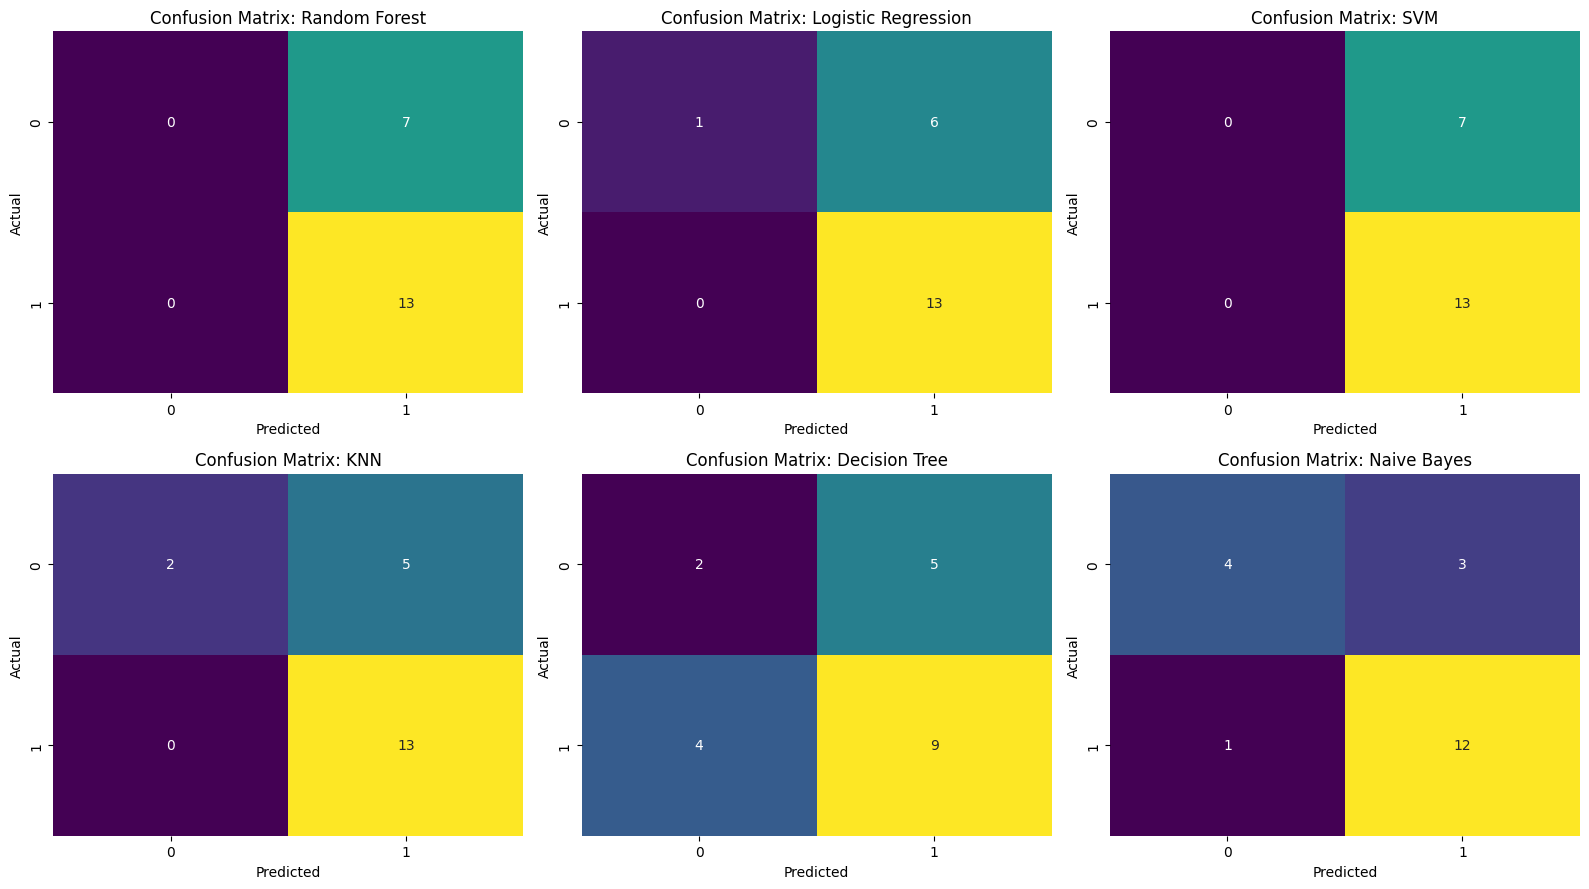

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming models are already trained and predictions are made as 'y_pred'
# Here, 'models' is a dictionary of trained models and 'X_test_scaled', 'y_test' are your test set

# Create the confusion matrix for each model
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Loop through the models to plot confusion matrix for each model
for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)  # Get predictions for each model
    cm = confusion_matrix(y_test, y_pred)  # Compute confusion matrix

    # Determine the subplot position (2 rows, 3 columns)
    row = i // 3  # Row index (0 or 1)
    col = i % 3   # Column index (0, 1, or 2)

    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', cbar=False,
                xticklabels=['0', '1'], yticklabels=['0', '1'], ax=axes[row, col])
    axes[row, col].set_title(f'Confusion Matrix: {name}')
    axes[row, col].set_xlabel('Predicted')
    axes[row, col].set_ylabel('Actual')

# Adjust layout
plt.tight_layout()
plt.show()

### **Dev and Cal Market Concentration using proper approach to indicate how technology business in Thailand looks like.**

Herfindahl-Hirschman Index (HHI) before merge: 3325.73
Herfindahl-Hirschman Index (HHI) after merge: 3350.72


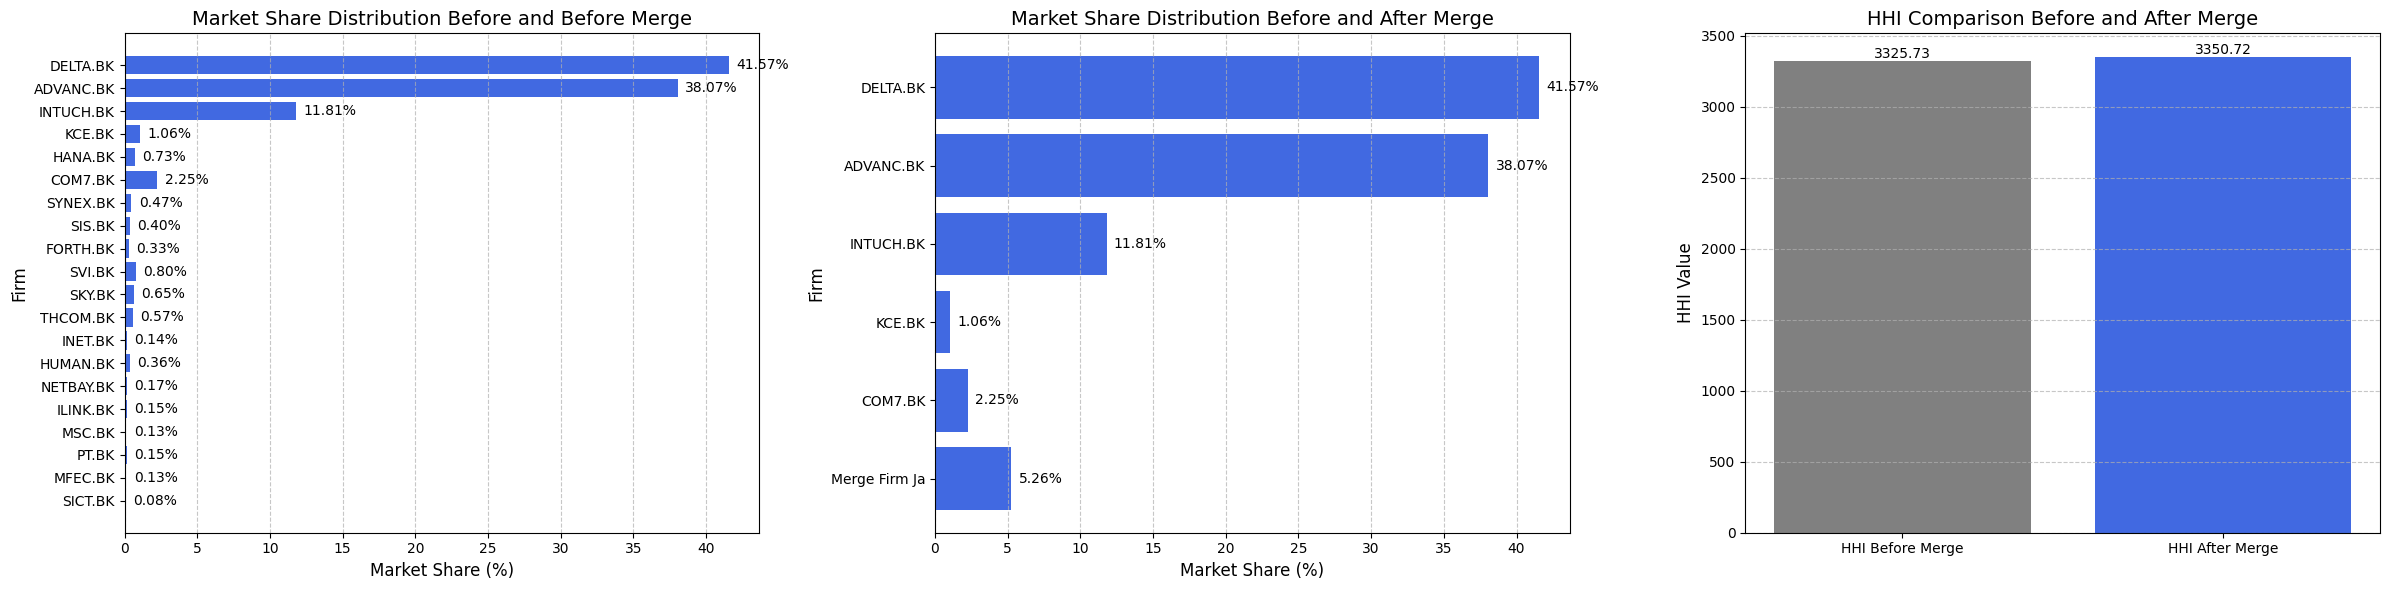

In [28]:
# Re-import necessary libraries after execution state reset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Function to calculate the Herfindahl-Hirschman Index (HHI)
def calculate_hhi(df):
    market_shares = df['Market Share']
    hhi = (market_shares ** 2).sum()  # Sum of squared market shares
    return hhi

# Identify firms with market share < 1% and merge them into 'Merge Firm Ja'
merged_df = test_df.copy()
merged_df['Firm'] = merged_df.apply(
    lambda row: 'Merge Firm Ja' if row['Market Share'] < 1 else row['Stock'], axis=1
)

# Calculate the new market share for 'Merge Firm Ja'
merged_market_share = merged_df[merged_df['Firm'] == 'Merge Firm Ja'].groupby('Firm')['Market Share'].sum()
merged_df.loc[merged_df['Firm'] == 'Merge Firm Ja', 'Market Share'] = merged_market_share.values[0]

# Remove individual firms that were merged into 'Merge Firm Ja'
merged_df = merged_df[merged_df['Firm'] != 'Merge Firm Ja']

# Append the merged firm to the DataFrame
merged_df = pd.concat([merged_df, pd.DataFrame({'Firm': ['Merge Firm Ja'], 'Market Share': [merged_market_share.values[0]]})], ignore_index=True)

# Calculate HHI before the merge
hhi_before = calculate_hhi(test_df)

# Calculate HHI after the merge
hhi_after = calculate_hhi(merged_df)

# Display the results
print(f"Herfindahl-Hirschman Index (HHI) before merge: {hhi_before:.2f}")
print(f"Herfindahl-Hirschman Index (HHI) after merge: {hhi_after:.2f}")

# Create a figure with two subplots: one for market share and one for HHI comparison
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 6))

# Plot bar chart for market share distribution
axes[0].barh(test_df["Stock"], test_df["Market Share"], color="royalblue")
axes[0].set_xlabel("Market Share (%)", fontsize=12)
axes[0].set_ylabel("Firm", fontsize=12)
axes[0].set_title("Market Share Distribution Before and Before Merge", fontsize=14)
axes[0].invert_yaxis()  # Invert y-axis for better readability

# Annotate market share values
for index, value in enumerate(test_df["Market Share"]):
    axes[0].text(value + 0.5, index, f"{value:.2f}%", va="center", fontsize=10)

axes[0].grid(axis="x", linestyle="--", alpha=0.7)

# Plot bar chart for market share distribution
axes[1].barh(merged_df["Firm"], merged_df["Market Share"], color="royalblue")
axes[1].set_xlabel("Market Share (%)", fontsize=12)
axes[1].set_ylabel("Firm", fontsize=12)
axes[1].set_title("Market Share Distribution Before and After Merge", fontsize=14)
axes[1].invert_yaxis()  # Invert y-axis for better readability

# Annotate market share values
for index, value in enumerate(merged_df["Market Share"]):
    axes[1].text(value + 0.5, index, f"{value:.2f}%", va="center", fontsize=10)

axes[1].grid(axis="x", linestyle="--", alpha=0.7)

# Plot bar chart for HHI before and after merge
hhis = [hhi_before, hhi_after]
labels = ["HHI Before Merge", "HHI After Merge"]
axes[2].bar(labels, hhis, color=["gray", "royalblue"])
axes[2].set_ylabel("HHI Value", fontsize=12)
axes[2].set_title("HHI Comparison Before and After Merge", fontsize=14)

# Annotate HHI values
for i, value in enumerate(hhis):
    axes[2].text(i, value + 20, f"{value:.2f}", ha="center", fontsize=10)

axes[2].grid(axis="y", linestyle="--", alpha=0.7)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


📊 **Interpretation of the Herfindahl-Hirschman Index (HHI) Before and After the Merge**

🔹 **1. HHI Before the Merge: 3325.73**
- The **Herfindahl-Hirschman Index (HHI)** measures **market concentration**.
  - **Higher HHI** → More concentrated market, with fewer firms holding a larger market share.
  - **Lower HHI** → More fragmented market, with many firms sharing the market.
- **HHI = 3325.73** before the merge suggests a **fairly concentrated** market with a few dominant firms.



🔹 **2. HHI After the Merge: 3350.72**
- After merging firms with **less than 1% market share** into a new entity, **'Merge Firm Ja'**, the **HHI increased slightly to 3350.72**.
- **Key Implications:**
  - **Market concentration increased slightly** after the merge.
  - **Merged firms’ market share (5.26%)** was consolidated under one entity.
  - **The increase is moderate**, meaning the overall market structure remains largely unchanged.



🔹 **3. Market Share Changes**
- **'Merge Firm Ja' now holds 5.26% of the market**, absorbing firms that previously had **less than 1% market share individually**.
- **Key Observations:**
  - Firms that were merged no longer appear **individually** in the dataset.
  - The **total market share remains unchanged**, but its **distribution has shifted**.
  - The **market is slightly more concentrated**, but competition is still present.



📌 **Conclusion**
- **Moderate increase in market concentration** due to merging **smaller firms**.
- The **increase in HHI is not substantial**, meaning the **competitive dynamics have not changed significantly**.
- **Strategic Benefit:** The merge **reduces market fragmentation** by consolidating small firms **without drastically altering competition**.



🔹 **Additional Thoughts**
- **A larger HHI increase** would indicate a **more significant shift in market power**.
- The **minor increase** suggests that **the merged firms were too small individually** to significantly impact the market.
- **Future mergers or consolidations** could **further increase market concentration**, potentially **reducing competition** if larger firms are involved.

🔍 **Overall, the merger creates a more streamlined market structure but does not fundamentally alter competition.** 🚀


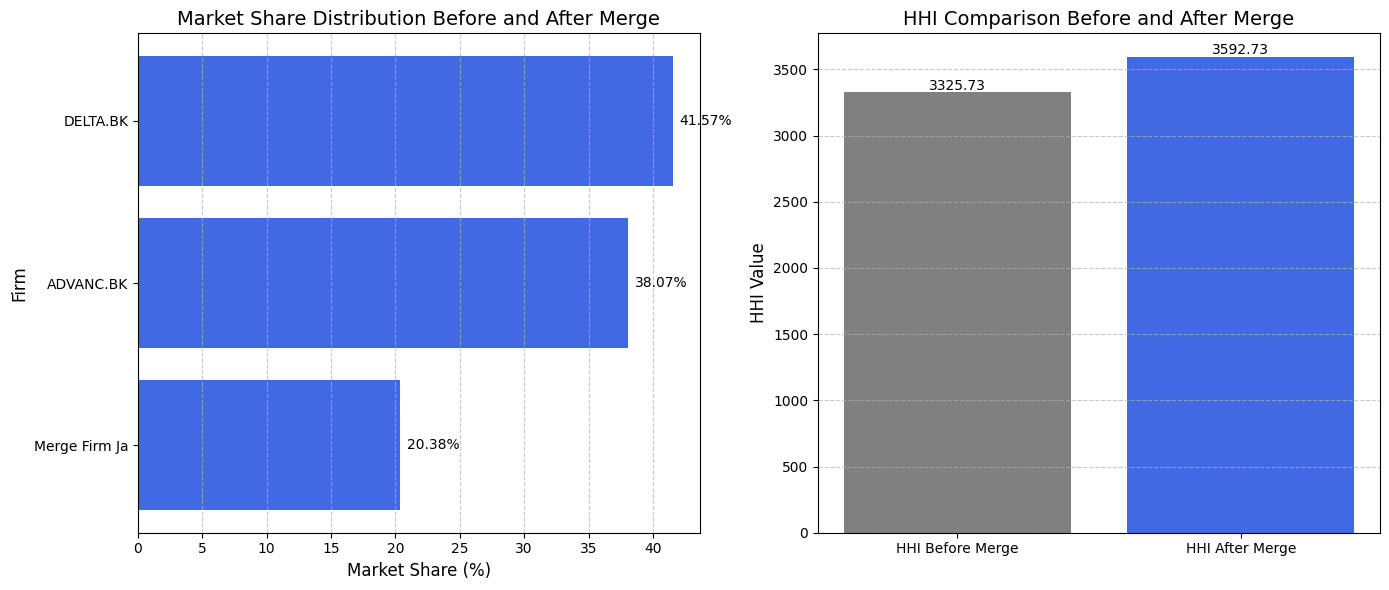

In [29]:
# Adjust the merging condition: Merge firms with market share < 12% into 'Merge Firm Ja'
merged_df = test_df.copy()
merged_df['Firm'] = merged_df.apply(
    lambda row: 'Merge Firm Ja' if row['Market Share'] < 12 else row['Stock'], axis=1
)

# Calculate the new market share for 'Merge Firm Ja'
merged_market_share = merged_df[merged_df['Firm'] == 'Merge Firm Ja'].groupby('Firm')['Market Share'].sum()
merged_df.loc[merged_df['Firm'] == 'Merge Firm Ja', 'Market Share'] = merged_market_share.values[0]

# Remove individual firms that were merged into 'Merge Firm Ja'
merged_df = merged_df[merged_df['Firm'] != 'Merge Firm Ja']

# Append the merged firm to the DataFrame
merged_df = pd.concat([merged_df, pd.DataFrame({'Firm': ['Merge Firm Ja'], 'Market Share': [merged_market_share.values[0]]})], ignore_index=True)

# Calculate HHI before and after the merge
hhi_before = calculate_hhi(test_df)
hhi_after = calculate_hhi(merged_df)

# Sort firms by market share for better visualization
merged_df_sorted = merged_df.sort_values(by="Market Share", ascending=False)

# Create a figure with two subplots: one for market share and one for HHI comparison
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Plot bar chart for market share distribution
axes[0].barh(merged_df_sorted["Firm"], merged_df_sorted["Market Share"], color="royalblue")
axes[0].set_xlabel("Market Share (%)", fontsize=12)
axes[0].set_ylabel("Firm", fontsize=12)
axes[0].set_title("Market Share Distribution Before and After Merge", fontsize=14)
axes[0].invert_yaxis()  # Invert y-axis for better readability

# Annotate market share values
for index, value in enumerate(merged_df_sorted["Market Share"]):
    axes[0].text(value + 0.5, index, f"{value:.2f}%", va="center", fontsize=10)

axes[0].grid(axis="x", linestyle="--", alpha=0.7)

# Plot bar chart for HHI before and after merge
hhis = [hhi_before, hhi_after]
labels = ["HHI Before Merge", "HHI After Merge"]
axes[1].bar(labels, hhis, color=["gray", "royalblue"])
axes[1].set_ylabel("HHI Value", fontsize=12)
axes[1].set_title("HHI Comparison Before and After Merge", fontsize=14)

# Annotate HHI values
for i, value in enumerate(hhis):
    axes[1].text(i, value + 20, f"{value:.2f}", ha="center", fontsize=10)

axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

### **Dev Simulation for M&A Technology Listed Companies and present how the Tech Industry will change and reshape to more monopoly market?**

🚀 **Simulating Mergers & Acquisitions (M&A) in the Technology Sector**

**Objective**
To simulate **mergers & acquisitions (M&A)** in the **technology sector** and analyze how the industry may shift toward a **monopoly market**, we will:

- **Load the market share data** of technology companies.
- **Simulate multiple M&A scenarios**, progressively merging firms to analyze **market concentration**.
- **Compute and visualize HHI changes**, illustrating how consolidation leads to **higher industry dominance**.


**🔹 Steps in the M&A Simulation**
**1️⃣ Base Market**  
Start with the **current market distribution** of technology firms.

**2️⃣ Initial Mergers (Small Firms Consolidation)**  
- Merge **smaller firms** (e.g., **< 5% market share**) into **larger competitors**.  
- This reduces market fragmentation and strengthens **mid-sized players**.

**3️⃣ Mid-Level Consolidation**  
- Merge **medium-sized firms** (e.g., **< 10% market share**) into a **few dominant firms**.  
- The market starts moving toward an **oligopolistic structure**.

**4️⃣ Near-Monopoly Formation**  
- Merge all but the **largest 2-3 firms**, creating a **highly concentrated market**.
- A few firms now **control the majority of the industry**.

**5️⃣ HHI Evolution (Market Concentration Growth)**  
- **Track how the Herfindahl-Hirschman Index (HHI)** increases, reflecting **rising monopoly power**.
- Higher **HHI values** indicate a **less competitive market**.

**6️⃣ Industry Impact Analysis**  
- **Interpret the results** to show how **tech dominance evolves** with each wave of M&A.
- Discuss potential **regulatory concerns** and **market competitiveness**.

📌 **Conclusion:** This simulation provides a **data-driven approach** to understanding how **mergers impact industry structure**, offering insights into the **potential risks and benefits** of consolidation in the tech sector. 🚀


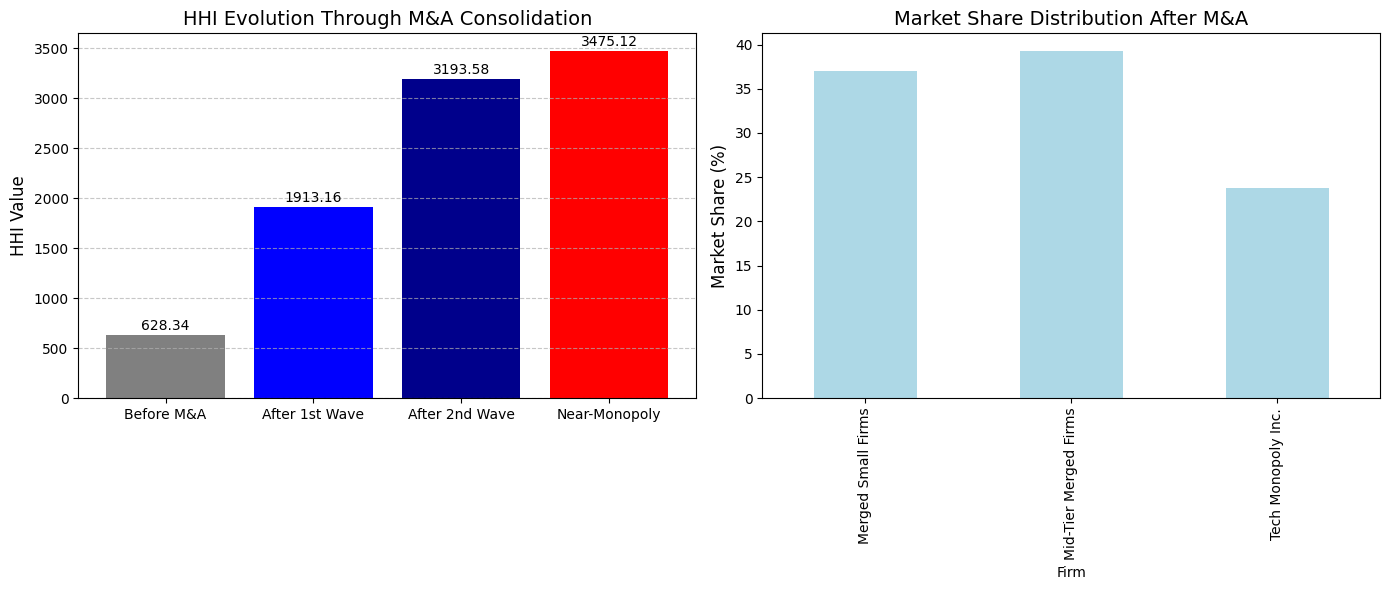

In [30]:


# Sample data (to simulate market share for this example)
data = {
    'Firm': ['AOT.BK', 'ADVANC.BK', 'AMATA.BK', 'AP.BK', 'BANPU.BK', 'BBL.BK', 'BEM.BK', 'BH.BK', 'BTS.BK', 'CPF.BK',
             'CPALL.BK', 'CRC.BK', 'EGCO.BK', 'GFPT.BK', 'HMPRO.BK', 'INTUCH.BK', 'IVL.BK', 'KBANK.BK', 'KCE.BK', 'MINT.BK',
             'MTC.BK', 'OSP.BK', 'PTT.BK', 'PTTEP.BK', 'PTTGC.BK', 'RATCH.BK', 'SCB.BK', 'SCC.BK', 'TISCO.BK', 'TRUE.BK',
             'TOP.BK', 'VGI.BK', 'WHART.BK'],
    'Market Share': [8.60, 11.94, 0.38, 0.42, 0.65, 4.24, 1.25, 2.10, 1.38, 2.84, 6.91, 2.54, 0.79, 0.16, 1.54, 3.70, 1.77, 5.42, 0.33, 2.36,
                     1.41, 0.69, 11.79, 6.47, 1.22, 0.88, 6.35, 2.84, 1.19, 5.55, 0.85, 0.93, 0.52]
}

# Create the initial DataFrame
df = pd.DataFrame(data)

# Function to calculate HHI
def calculate_hhi(df):
    market_shares = df["Market Share"]
    return (market_shares ** 2).sum()  # Sum of squared market shares

# Step 1: Initial HHI Calculation (before any M&A activity)
hhi_initial = calculate_hhi(df)

# Step 2: Simulate Mergers & Acquisitions

# First Merger Wave: Merge firms with < 5% market share into "Merged Small Firms"
df["Firm"] = df.apply(
    lambda row: "Merged Small Firms" if row["Market Share"] < 5 else row["Firm"], axis=1)

# Recalculate Market Share for Merged Firm
merged_market_share_1 = df[df["Firm"] == "Merged Small Firms"]["Market Share"].sum()

# Remove individual small firms and add the merged firm
df = df[df["Firm"] != "Merged Small Firms"]
df = pd.concat([df, pd.DataFrame({"Firm": ["Merged Small Firms"], "Market Share": [merged_market_share_1]})], ignore_index=True)

# Step 3: Recalculate HHI after first merger wave
hhi_after_first_wave = calculate_hhi(df)

# Second Merger Wave: Merge firms with < 10% market share into "Mid-Tier Merged Firms"
df["Firm"] = df.apply(
    lambda row: "Mid-Tier Merged Firms" if row["Market Share"] < 10 else row["Firm"], axis=1)

# Recalculate Market Share for Mid-Tier Merge
merged_market_share_2 = df[df["Firm"] == "Mid-Tier Merged Firms"]["Market Share"].sum()

# Remove individual firms and add the merged mid-tier firm
df = df[df["Firm"] != "Mid-Tier Merged Firms"]
df = pd.concat([df, pd.DataFrame({"Firm": ["Mid-Tier Merged Firms"], "Market Share": [merged_market_share_2]})], ignore_index=True)

# Step 4: Recalculate HHI after second merger wave
hhi_after_second_wave = calculate_hhi(df)

# Third Merger Wave: Consolidate into near-monopoly (final scenario)
df["Firm"] = df.apply(
    lambda row: "Tech Monopoly Inc." if row["Market Share"] < 15 else row["Firm"], axis=1)

# Recalculate Market Share for Monopoly
merged_market_share_3 = df[df["Firm"] == "Tech Monopoly Inc."]["Market Share"].sum()

# Remove individual firms and add the final monopolized firm
df = df[df["Firm"] != "Tech Monopoly Inc."]
df = pd.concat([df, pd.DataFrame({"Firm": ["Tech Monopoly Inc."], "Market Share": [merged_market_share_3]})], ignore_index=True)

# Step 5: Final HHI Calculation (Near-Monopoly)
hhi_final = calculate_hhi(df)

# Plot the evolution of HHI over different merger waves
hhi_values = [hhi_initial, hhi_after_first_wave, hhi_after_second_wave, hhi_final]
labels = ["Before M&A", "After 1st Wave", "After 2nd Wave", "Near-Monopoly"]

plt.figure(figsize=(14, 6))

# Plot HHI Evolution
plt.subplot(1, 2, 1)
plt.bar(labels, hhi_values, color=["gray", "blue", "darkblue", "red"])
plt.ylabel("HHI Value", fontsize=12)
plt.title("HHI Evolution Through M&A Consolidation", fontsize=14)

# Annotate values
for i, value in enumerate(hhi_values):
    plt.text(i, value + 50, f"{value:.2f}", ha="center", fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.7)

# Plot Market Share Evolution
plt.subplot(1, 2, 2)
df.plot(kind='bar', x='Firm', y='Market Share', legend=False, color='lightblue', ax=plt.gca())
plt.ylabel("Market Share (%)", fontsize=12)
plt.title("Market Share Distribution After M&A", fontsize=14)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()